In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import joblib
import warnings
warnings.filterwarnings('ignore')


In [173]:
df = pd.read_csv('BankChurners.csv')
print('Shape of the dataset:', df.shape)
print('First 5 rows of the dataset:')
print(df.head())

Shape of the dataset: (10127, 23)
First 5 rows of the dataset:
   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ... 

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

# Dropping Last two cols of the dataset

In [175]:
df = df.drop(columns=[
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
])

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [177]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [178]:
# Chesking for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


In [179]:
# target variable distribution
print('Attrition_Flag value counts:  ')
print(df['Attrition_Flag'].value_counts())
print('Attrition_Flag value counts (percentage):  ')
print(df['Attrition_Flag'].value_counts(normalize=True) * 100)

Attrition_Flag value counts:  
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag value counts (percentage):  
Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Numeric columns: Index(['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')


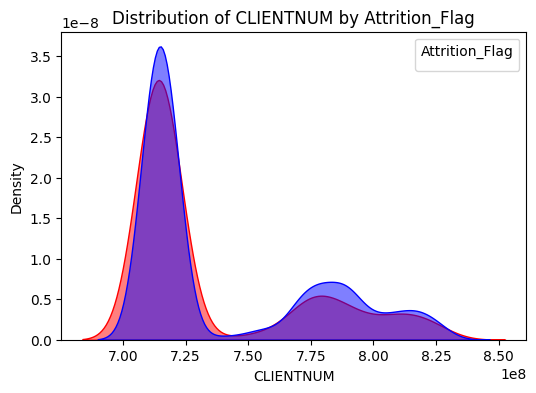

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


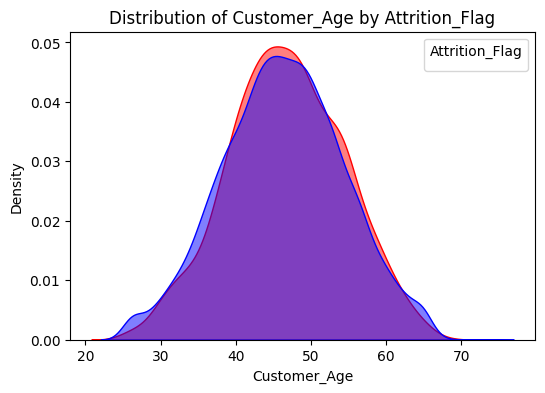

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


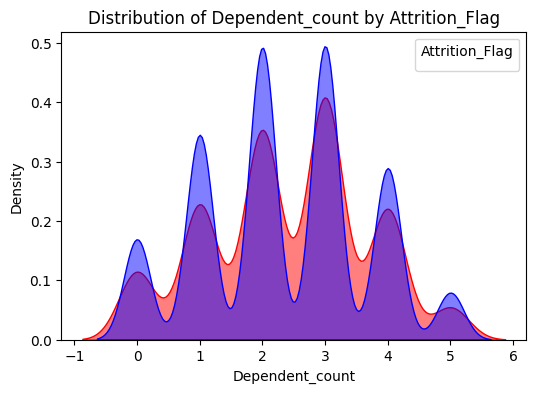

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


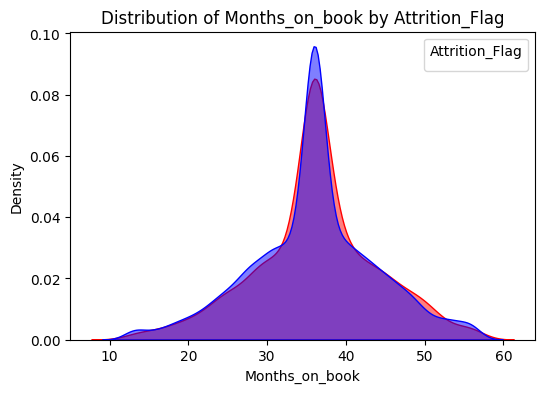

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


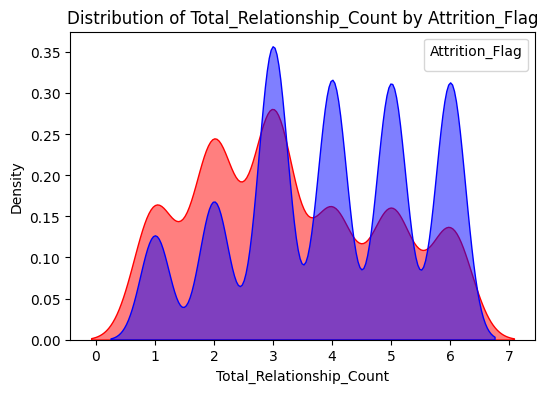

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


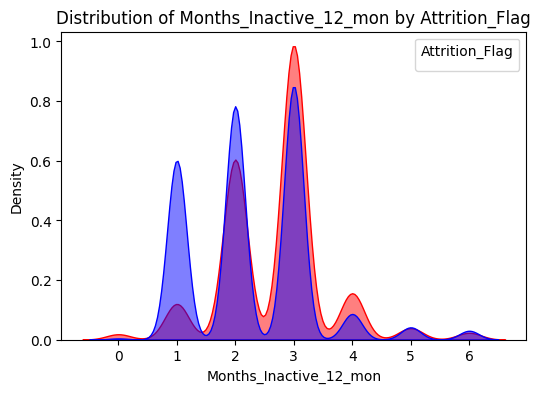

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


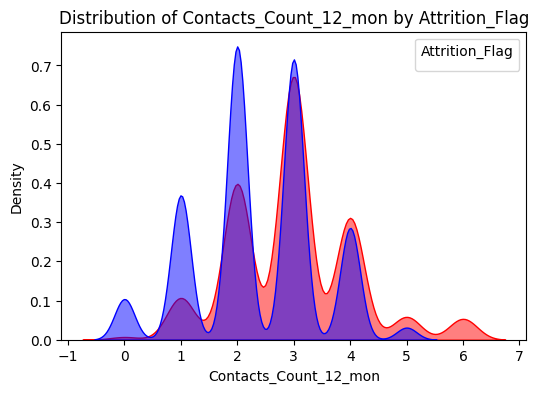

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


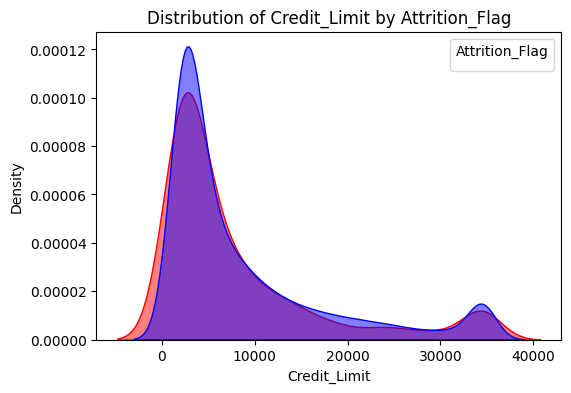

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


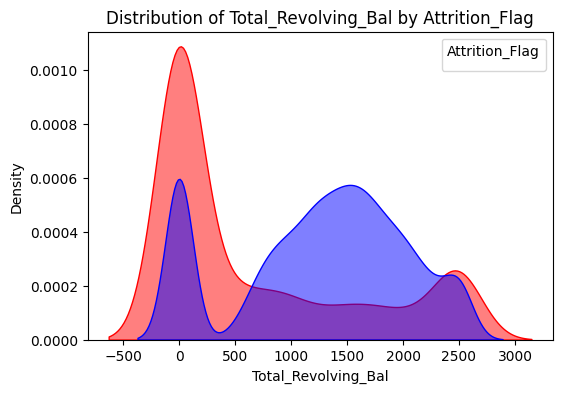

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


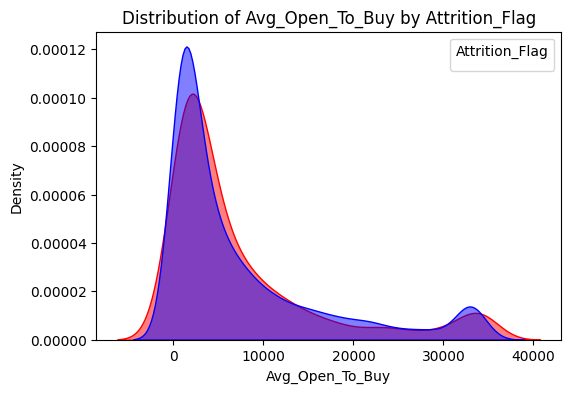

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


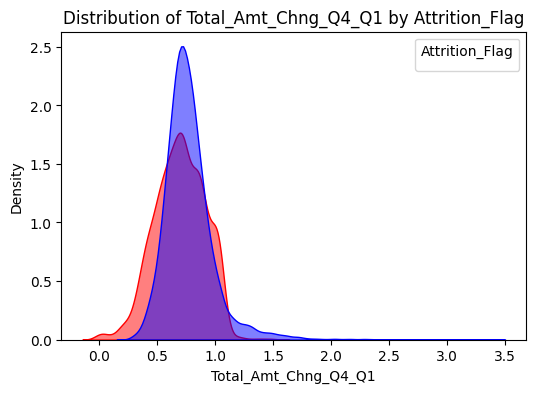

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


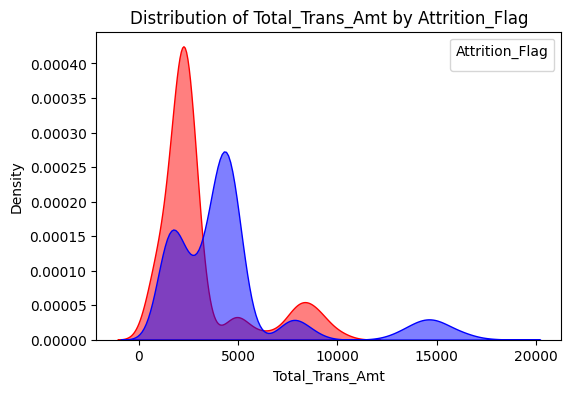

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


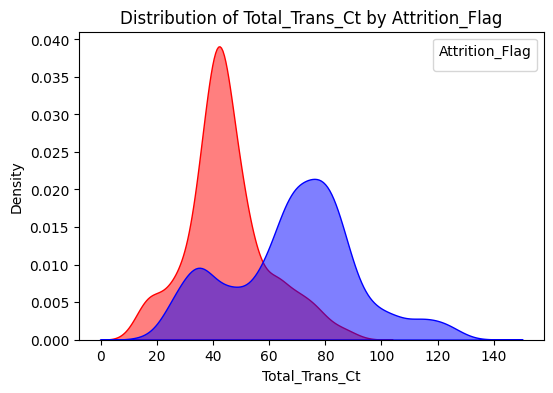

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


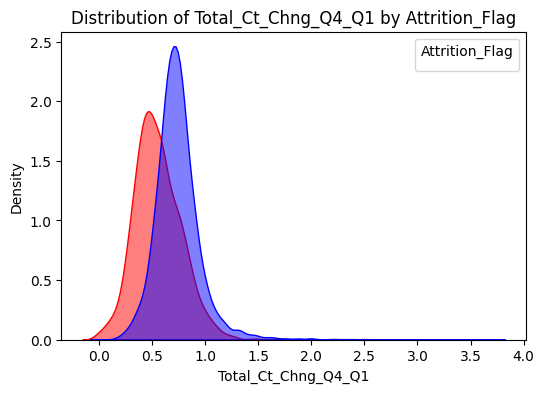

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


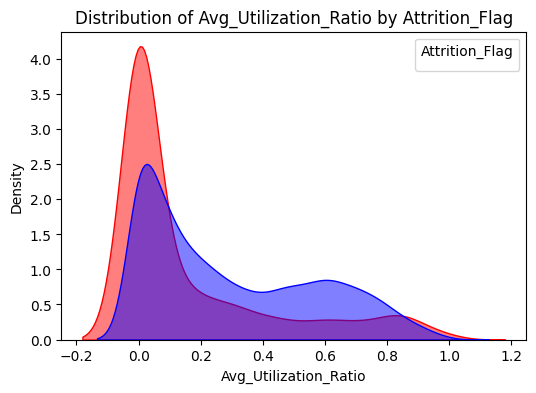

In [180]:
neumeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:", neumeric_cols)
for col in neumeric_cols:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data = df, x = col, hue=df['Attrition_Flag'], fill=True ,common_norm=False,alpha=0.5,palette={'Existing Customer': 'blue', 'Attrited Customer': 'red'})
    plt.title(f'Distribution of {col} by Attrition_Flag')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend(title='Attrition_Flag')
    plt.show()

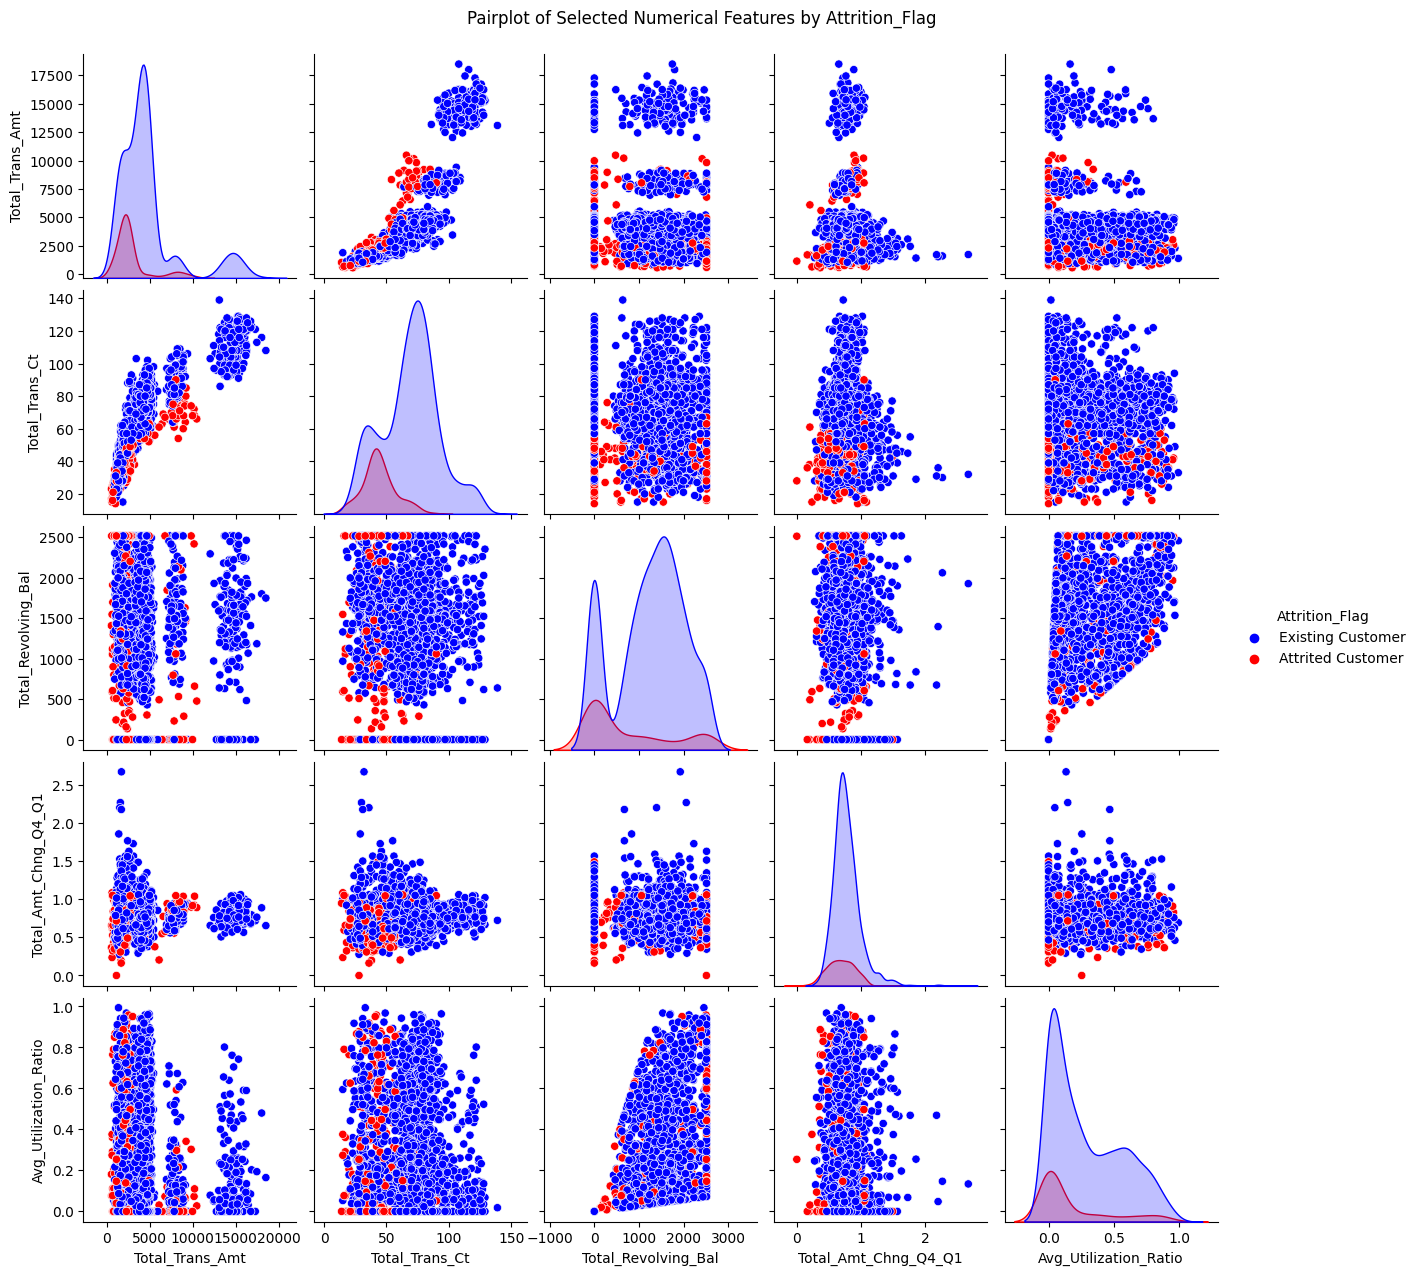

In [181]:
analysis_col =['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
sns.pairplot(df.sample(frac=0.2), vars=analysis_col, hue='Attrition_Flag', palette={'Existing Customer': 'blue', 'Attrited Customer': 'red'})
plt.suptitle('Pairplot of Selected Numerical Features by Attrition_Flag', y=1.02)
plt.show()

# Feature Engineering

In [182]:
#copying the original dataset
df_original = df.copy()
df_original.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [183]:
# Engineered features

df['avg_amt_per_txn'] = df['Total_Trans_Amt'] / df['Total_Trans_Ct']
df['engagement_score'] = df['Total_Trans_Ct'] * df['Avg_Utilization_Ratio']
df['spend_change_intensity'] = df['Total_Trans_Amt'] * df['Total_Amt_Chng_Q4_Q1']

In [184]:
# converting target variable to binary
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

In [185]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_amt_per_txn,engagement_score,spend_change_intensity
0,768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,...,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,2.562,1527.240
1,818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,3.465,1989.431
2,713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,0.000,4894.878
3,769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,15.200,1645.255
4,709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,2.175,816,28,2.500,0.000,29.142857,0.000,1774.800


<Axes: >

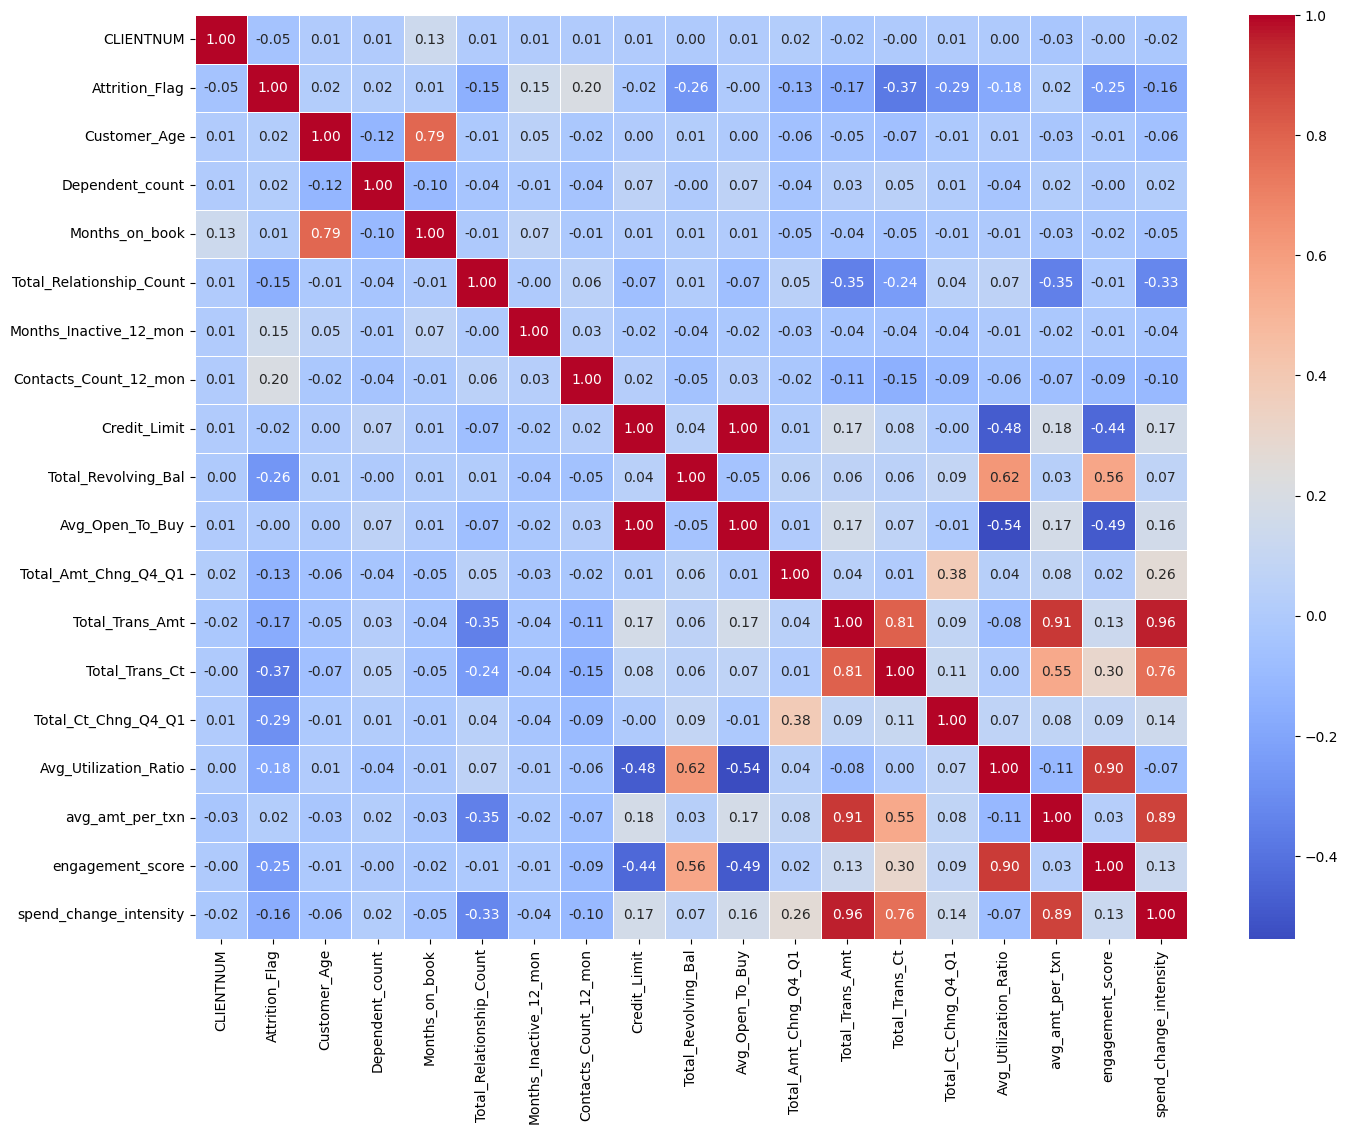

In [186]:
import seaborn as sns
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm',annot=True, fmt=".2f", linewidths=0.5)

In [187]:
df.corr(numeric_only=True)

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,avg_amt_per_txn,engagement_score,spend_change_intensity
CLIENTNUM,1.000000,-0.046430,0.007613,0.006772,0.134588,0.006907,0.005729,0.005694,0.005708,0.000825,0.005633,0.017369,-0.019692,-0.002961,0.007696,0.000266,-0.031434,-0.000235,-0.017914
Attrition_Flag,-0.046430,1.000000,0.018203,0.018991,0.013687,-0.150005,0.152449,0.204491,-0.023873,-0.263053,-0.000285,-0.131063,-0.168598,-0.371403,-0.290054,-0.178410,0.016246,-0.245027,-0.161962
Customer_Age,0.007613,0.018203,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114,-0.029877,-0.012757,-0.058910
Dependent_count,0.006772,0.018991,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135,0.018707,-0.004536,0.015829
Months_on_book,0.134588,0.013687,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541,-0.029198,-0.021382,-0.048238
Total_Relationship_Count,0.006907,-0.150005,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663,-0.346583,-0.012300,-0.325461
Months_Inactive_12_mon,0.005729,0.152449,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503,-0.016782,-0.011025,-0.036050
Contacts_Count_12_mon,0.005694,0.204491,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471,-0.073186,-0.094797,-0.102686
Credit_Limit,0.005708,-0.023873,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965,0.175635,-0.440114,0.167791
Total_Revolving_Bal,0.000825,-0.263053,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022,0.033255,0.561203,0.070549


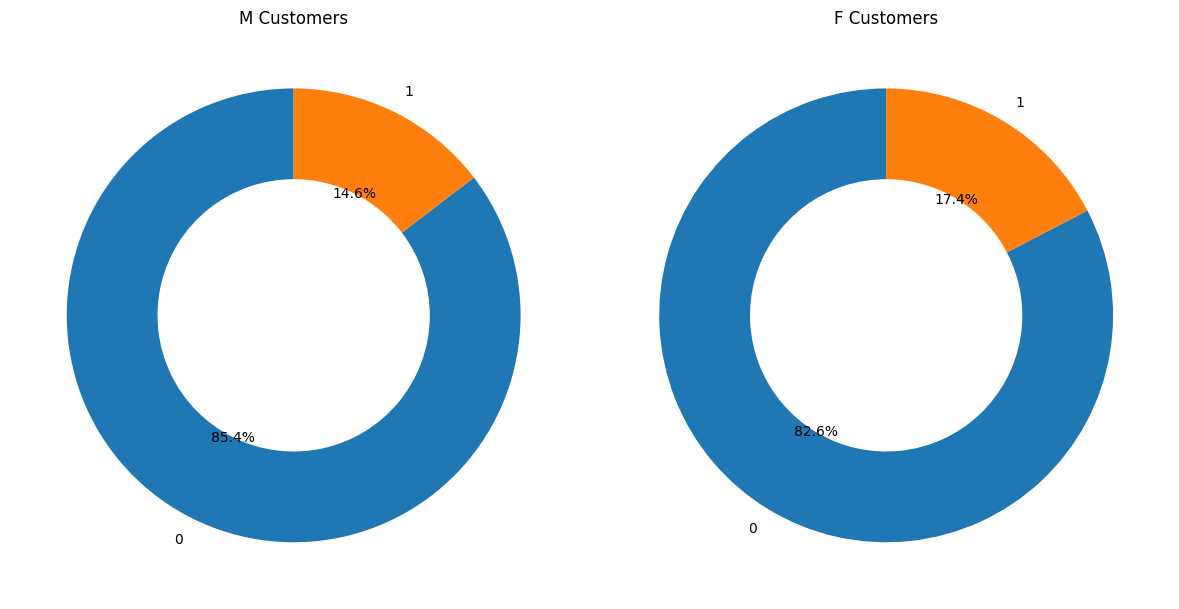

In [188]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

genders = ['M', 'F']

for i, gender in enumerate(genders):
    subset = df[df['Gender'] == gender]
    counts = subset['Attrition_Flag'].value_counts()
    
    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.4}
    )
    
    axes[i].set_title(f"{gender} Customers")

plt.tight_layout()
plt.show()

In [189]:
categorical = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical)

Categorical columns: Index(['Gender', 'Education_Level', 'Marital_Status', 'Income_Category',
       'Card_Category'],
      dtype='object')


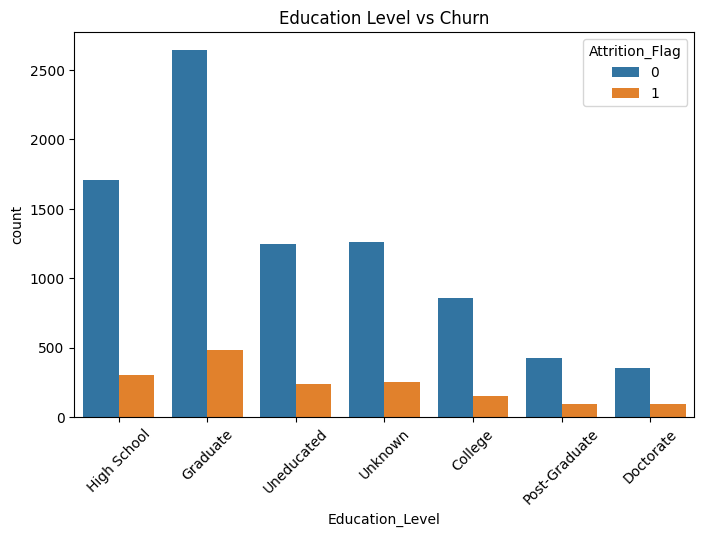

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Education_Level', hue='Attrition_Flag')
plt.xticks(rotation=45)
plt.title("Education Level vs Churn")
plt.show()

In [191]:
pd.crosstab(df['Education_Level'], df['Attrition_Flag'], normalize='index')

Attrition_Flag,0,1
Education_Level,,
College,0.847976,0.152024
Doctorate,0.789357,0.210643
Graduate,0.844309,0.155691
High School,0.847988,0.152012
Post-Graduate,0.821705,0.178295
Uneducated,0.840619,0.159381
Unknown,0.831468,0.168532


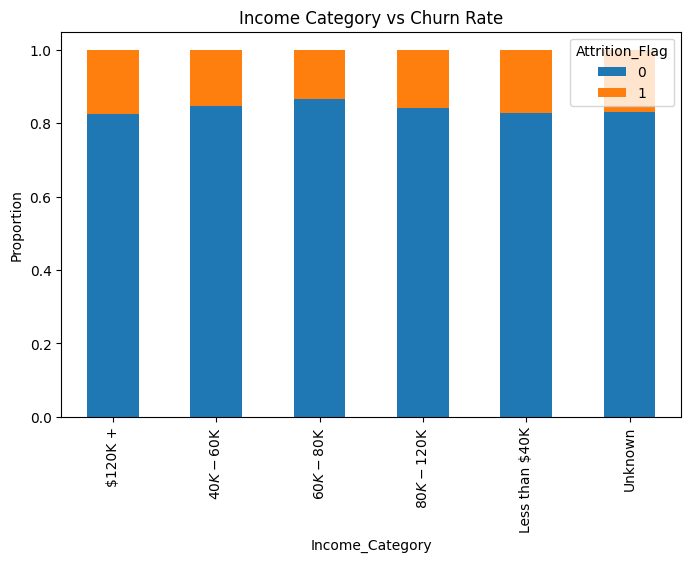

In [192]:
ct = pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Income Category vs Churn Rate")
plt.ylabel("Proportion")
plt.show()

In [193]:
df = pd.get_dummies(df, columns=['Education_Level', 'Income_Category'], drop_first=True)

In [194]:
drop_cols = [
    'CLIENTNUM',      
    'spend_change_intensity',
    'avg_amt_per_txn',
    'Avg_Open_To_Buy'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [195]:
df = pd.get_dummies(
    df,
    columns=['Gender', 'Marital_Status', 'Card_Category'],
    drop_first=True
)

In [196]:
df.head(10)


,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,...,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,3,39,5,1,3,12691.0,777,1.335,...,False,False,False,True,True,False,False,False,False,False
1,0,49,5,44,6,1,2,8256.0,864,1.541,...,False,True,False,False,False,True,False,False,False,False
2,0,51,3,36,4,1,0,3418.0,0,2.594,...,True,False,False,True,True,False,False,False,False,False
3,0,40,4,34,3,4,1,3313.0,2517,1.405,...,False,True,False,False,False,False,True,False,False,False
4,0,40,3,21,5,1,0,4716.0,0,2.175,...,False,False,False,True,True,False,False,False,False,False
5,0,44,2,36,3,1,2,4010.0,1247,1.376,...,False,False,False,True,True,False,False,False,False,False
6,0,51,4,46,6,1,3,34516.0,2264,1.975,...,False,False,False,True,True,False,False,True,False,False
7,0,32,0,27,2,2,2,29081.0,1396,2.204,...,False,False,False,True,False,False,True,False,False,True
8,0,37,3,36,5,2,0,22352.0,2517,3.355,...,False,False,False,True,False,True,False,False,False,False
9,0,48,2,36,6,3,3,11656.0,1677,1.524,...,True,False,False,True,False,True,False,False,False,False


In [197]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Dependent_count                 10127 non-null  int64  
 3   Months_on_book                  10127 non-null  int64  
 4   Total_Relationship_Count        10127 non-null  int64  
 5   Months_Inactive_12_mon          10127 non-null  int64  
 6   Contacts_Count_12_mon           10127 non-null  int64  
 7   Credit_Limit                    10127 non-null  float64
 8   Total_Revolving_Bal             10127 non-null  int64  
 9   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 10  Total_Trans_Amt                 10127 non-null  int64  
 11  Total_Trans_Ct                  10127 non-null  int64  
 12  Total_Ct_Chng_Q4_Q1             

In [198]:
df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'engagement_score',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown',
       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',
       'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold',
       'Card_Category_Platinum', 'Card_Category_Silver'],
      dtype='object')

In [199]:
df['engagement_score'].head(20)

0      2.562
1      3.465
2      0.000
3     15.200
4      0.000
5      7.464
6      2.046
7      1.728
8      2.712
9      4.608
10     9.114
11     4.524
12     0.000
13     6.435
14     8.091
15     6.210
16     2.106
17     1.995
18    23.640
19     1.680
Name: engagement_score, dtype: float64

In [200]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Dependent_count                 10127 non-null  int64  
 3   Months_on_book                  10127 non-null  int64  
 4   Total_Relationship_Count        10127 non-null  int64  
 5   Months_Inactive_12_mon          10127 non-null  int64  
 6   Contacts_Count_12_mon           10127 non-null  int64  
 7   Credit_Limit                    10127 non-null  float64
 8   Total_Revolving_Bal             10127 non-null  int64  
 9   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 10  Total_Trans_Amt                 10127 non-null  int64  
 11  Total_Trans_Ct                  10127 non-null  int64  
 12  Total_Ct_Chng_Q4_Q1             

In [202]:
drop_cols = [
    'Credit_Limit',          
    'Dependent_count',       
    
]

df = df.drop(columns=drop_cols, errors='ignore')

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Months_on_book                  10127 non-null  int64  
 3   Total_Relationship_Count        10127 non-null  int64  
 4   Months_Inactive_12_mon          10127 non-null  int64  
 5   Contacts_Count_12_mon           10127 non-null  int64  
 6   Total_Revolving_Bal             10127 non-null  int64  
 7   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 8   Total_Trans_Amt                 10127 non-null  int64  
 9   Total_Trans_Ct                  10127 non-null  int64  
 10  Total_Ct_Chng_Q4_Q1             10127 non-null  float64
 11  Avg_Utilization_Ratio           10127 non-null  float64
 12  engagement_score                

In [204]:
df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Avg_Utilization_Ratio', 'engagement_score',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown',
       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',
       'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold',
       'Card_Category_Platinum', 'Card_Category_Silver'],
      dtype='object')

# Training Multiple Models

In [205]:
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

In [206]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=43, stratify=y
)

In [207]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


scores_logistic = []
scores_rf = []
scores_svm = []
scores_gb = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
   
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    

    lr = LogisticRegression(max_iter=1000, class_weight='balanced')
    lr.fit(X_train_scaled, y_train)
    y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]
    scores_logistic.append(roc_auc_score(y_val, y_prob_lr))
    

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_prob_rf = rf.predict_proba(X_val)[:, 1]
    scores_rf.append(roc_auc_score(y_val, y_prob_rf))
    

    svm = SVC(probability=True, class_weight='balanced')
    svm.fit(X_train_scaled, y_train)
    y_prob_svm = svm.predict_proba(X_val_scaled)[:, 1]
    scores_svm.append(roc_auc_score(y_val, y_prob_svm))
    
  
    gb = GradientBoostingClassifier(random_state=42)
    gb.fit(X_train, y_train)
    y_prob_gb = gb.predict_proba(X_val)[:, 1]
    scores_gb.append(roc_auc_score(y_val, y_prob_gb))
    
    print(f"\nFold {fold} done")


print("\nLogistic AUC:", scores_logistic, "Mean:", np.mean(scores_logistic))
print("Random Forest AUC:", scores_rf, "Mean:", np.mean(scores_rf))
print("SVM AUC:", scores_svm, "Mean:", np.mean(scores_svm))
print("Gradient Boosting AUC:", scores_gb, "Mean:", np.mean(scores_gb))


Fold 1 done

Fold 2 done

Fold 3 done

Fold 4 done

Fold 5 done

Logistic AUC: [0.9186485023457236, 0.9310880548538435, 0.9219547511312218, 0.9269574660633486, 0.9254262443438913] Mean: 0.9248150037476058
Random Forest AUC: [0.9853410321183689, 0.9912657885239985, 0.9824289592760181, 0.985379185520362, 0.9885040723981902] Mean: 0.9865838075673876
SVM AUC: [0.9523051245037892, 0.9633507758931793, 0.9500904977375566, 0.9603746606334842, 0.9538389140271494] Mean: 0.9559919945590318
Gradient Boosting AUC: [0.9888217250090221, 0.9921779141104294, 0.9851638009049772, 0.98750407239819, 0.9929285067873304] Mean: 0.9893192038419898


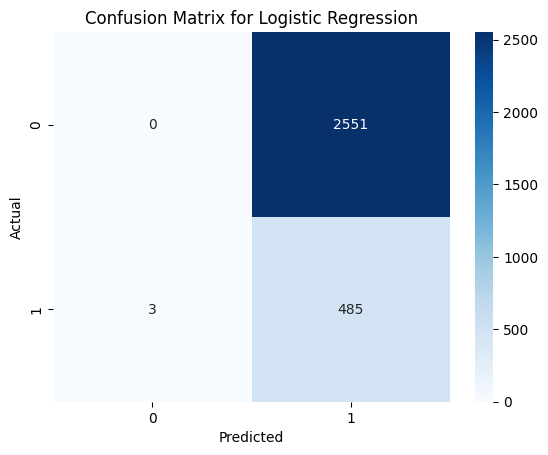

In [208]:
#confusion matrix for logistic regression
y_pred_lr = lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')   
plt.show()

In [209]:
#logistic regression classification report
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2551
           1       0.16      0.99      0.28       488

    accuracy                           0.16      3039
   macro avg       0.08      0.50      0.14      3039
weighted avg       0.03      0.16      0.04      3039



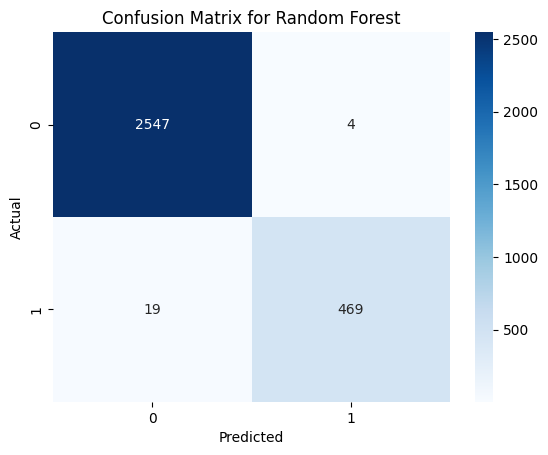

In [210]:
#confusion matrix for random forest
y_pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [211]:
#classification report for random forest
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2551
           1       0.99      0.96      0.98       488

    accuracy                           0.99      3039
   macro avg       0.99      0.98      0.99      3039
weighted avg       0.99      0.99      0.99      3039



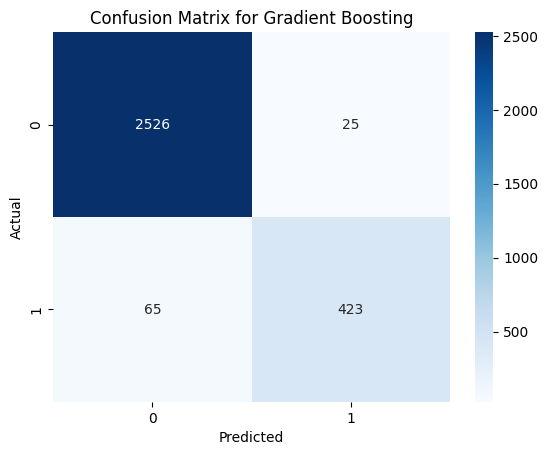

In [212]:
#confusion matrix for Gradient Boosting
y_pred_gb = gb.predict(X_test)
cm_gb = confusion_matrix(y_test, y_pred_gb) 
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()

In [213]:
#gradient boosting classification report
print("Classification Report for Gradient Boosting:")
print(classification_report(y_test, y_pred_gb)) 

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2551
           1       0.94      0.87      0.90       488

    accuracy                           0.97      3039
   macro avg       0.96      0.93      0.94      3039
weighted avg       0.97      0.97      0.97      3039



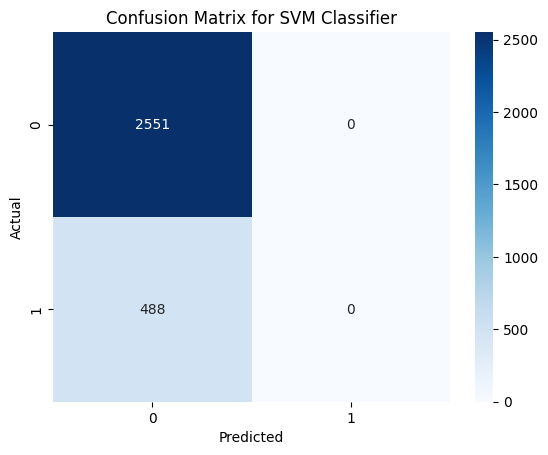

In [214]:
#confusion matrix for svm
y_pred_svm = svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)  
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

In [215]:
#classification report for svm
print("Classification Report for SVM Classifier:")
print(classification_report(y_test, y_pred_svm))

Classification Report for SVM Classifier:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2551
           1       0.00      0.00      0.00       488

    accuracy                           0.84      3039
   macro avg       0.42      0.50      0.46      3039
weighted avg       0.70      0.84      0.77      3039



In [216]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


scores_xgb = []
scores_cat = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
   
    xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=(len(y) - sum(y)) / sum(y),
        use_label_encoder=False
    )
    
    xgb.fit(X_train, y_train)
    y_prob_xgb = xgb.predict_proba(X_val)[:, 1]
    scores_xgb.append(roc_auc_score(y_val, y_prob_xgb))
    
   
    cat = CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=4,
        random_state=42,
        verbose=0
    )
    
    cat.fit(X_train, y_train)
    y_prob_cat = cat.predict_proba(X_val)[:, 1]
    scores_cat.append(roc_auc_score(y_val, y_prob_cat))
    
    print(f"\nFold {fold} done")


print("\nXGBoost AUC:", scores_xgb, "Mean:", np.mean(scores_xgb))
print("CatBoost AUC:", scores_cat, "Mean:", np.mean(scores_cat))


Fold 1 done

Fold 2 done

Fold 3 done

Fold 4 done

Fold 5 done

XGBoost AUC: [0.9908228076506677, 0.9943468062071454, 0.9890787330316742, 0.9916090497737557, 0.9950733031674208] Mean: 0.9921861399661328
CatBoost AUC: [0.9902038975099242, 0.9940671237820281, 0.9873158371040724, 0.9913556561085972, 0.9947402714932126] Mean: 0.991536557199567


Confusion Matrix: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      2551
           1       0.86      0.99      0.92       488

    accuracy                           0.97      3039
   macro avg       0.93      0.98      0.95      3039
weighted avg       0.98      0.97      0.97      3039



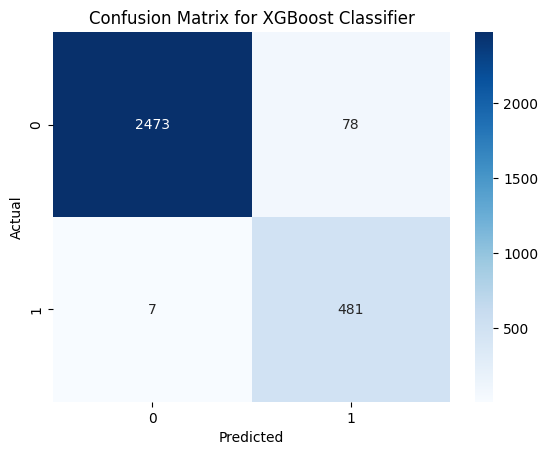

In [217]:
#confusion matrix and classification report for the best model (XGBoost)
y_pred_xgb = xgb.predict(X_test)
print("Confusion Matrix: XGBoost")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()

Confusion Matrix: CatBoost

Classification Report:


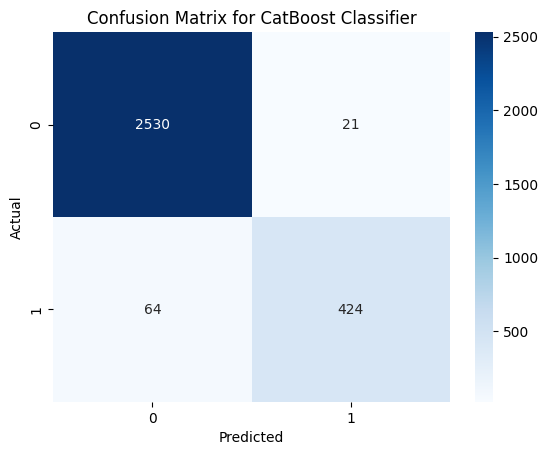

In [218]:
#Confusion matrix for CatBoost
y_pred_cat = cat.predict(X_test)
print("Confusion Matrix: CatBoost")
print("\nClassification Report:")
cm = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for CatBoost Classifier')
plt.show()

In [219]:
#xgboost classification report
print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      2551
           1       0.86      0.99      0.92       488

    accuracy                           0.97      3039
   macro avg       0.93      0.98      0.95      3039
weighted avg       0.98      0.97      0.97      3039



In [220]:
#catboost classification report
print("Classification Report for CatBoost:")
print(classification_report(y_test, y_pred_cat))

Classification Report for CatBoost:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2551
           1       0.95      0.87      0.91       488

    accuracy                           0.97      3039
   macro avg       0.96      0.93      0.95      3039
weighted avg       0.97      0.97      0.97      3039



# Using Hybrid model with Stacking Process

In [221]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier


In [222]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    class_weight='balanced',   
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight =(len(y) - sum(y)) / sum(y),  
    random_state=42,
    eval_metric='logloss'
)


In [223]:
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb)
    ],
    final_estimator= XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        #scale_pos_weight =(len(y) - sum(y)) / sum(y),
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),   
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1,
    passthrough=True
    
)


In [224]:
scores_stack = []

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    stack_model.fit(X_train, y_train)
    
    y_prob = stack_model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_prob)
    scores_stack.append(auc)
    
    print(f"Fold {fold} AUC: {auc:.4f}")

Fold 1 AUC: 0.9937
Fold 2 AUC: 0.9893
Fold 3 AUC: 0.9942
Fold 4 AUC: 0.9950
Fold 5 AUC: 0.9892
Fold 6 AUC: 0.9923
Fold 7 AUC: 0.9927
Fold 8 AUC: 0.9922
Fold 9 AUC: 0.9929
Fold 10 AUC: 0.9965


In [225]:
print(np.mean(scores_stack))

0.9927884170709866


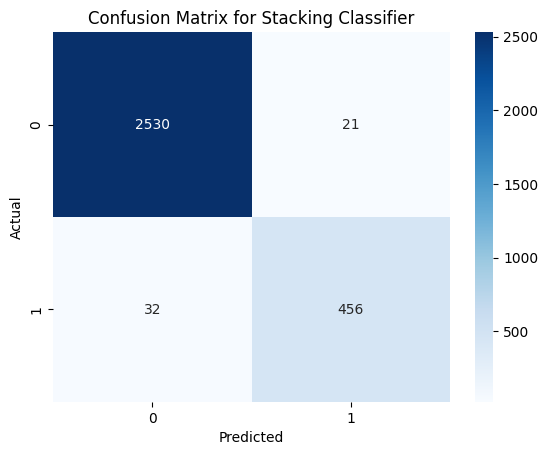

In [226]:
y_pred = stack_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Stacking Classifier')
plt.show()

In [227]:
#Threshold tuning for the stacking model(proposed_model)
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]
thresholds = 0.27
y_pred_thresh = (y_prob_stack >= thresholds).astype(int)
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2551
           1       0.91      0.98      0.94       488

    accuracy                           0.98      3039
   macro avg       0.95      0.98      0.97      3039
weighted avg       0.98      0.98      0.98      3039



In [228]:
#classification report for stacking model without threshold tuning
print("Classification Report for Stacking Classifier:")
print(classification_report(y_test, y_pred))

Classification Report for Stacking Classifier:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2551
           1       0.96      0.93      0.95       488

    accuracy                           0.98      3039
   macro avg       0.97      0.96      0.97      3039
weighted avg       0.98      0.98      0.98      3039



In [229]:
models = {
    
    "Random Forest": scores_rf,
    "Gradient Boosting": scores_gb,
    "XGBoost": scores_xgb,
    
    "Cat Boost": scores_cat,
    "Stacking": scores_stack
    
}
model_names = list(models.keys())
mean_scores = [np.mean(scores) for scores in models.values()]


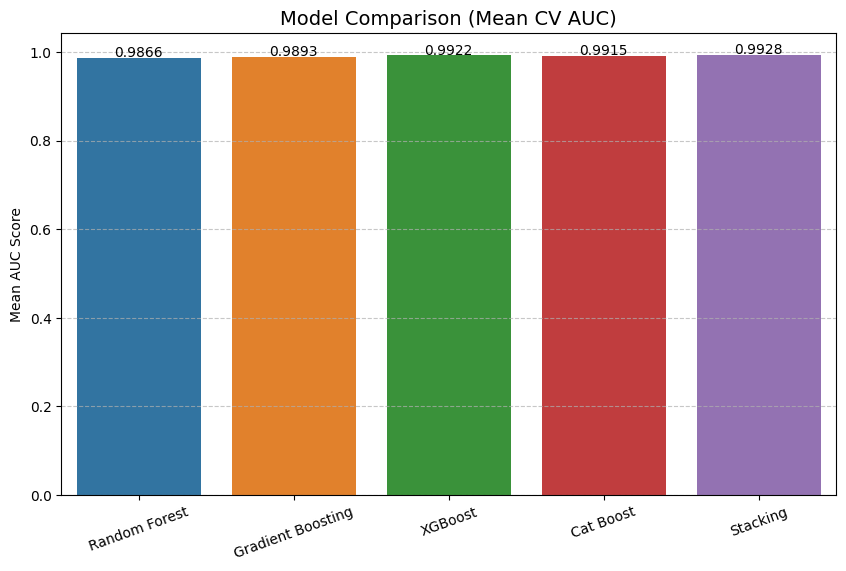

In [230]:
plt.figure(figsize=(10,6))
sns.barplot(x=model_names, y=mean_scores)

plt.title("Model Comparison (Mean CV AUC)", fontsize=14)
plt.ylabel("Mean AUC Score")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top
for i, v in enumerate(mean_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')

plt.show()

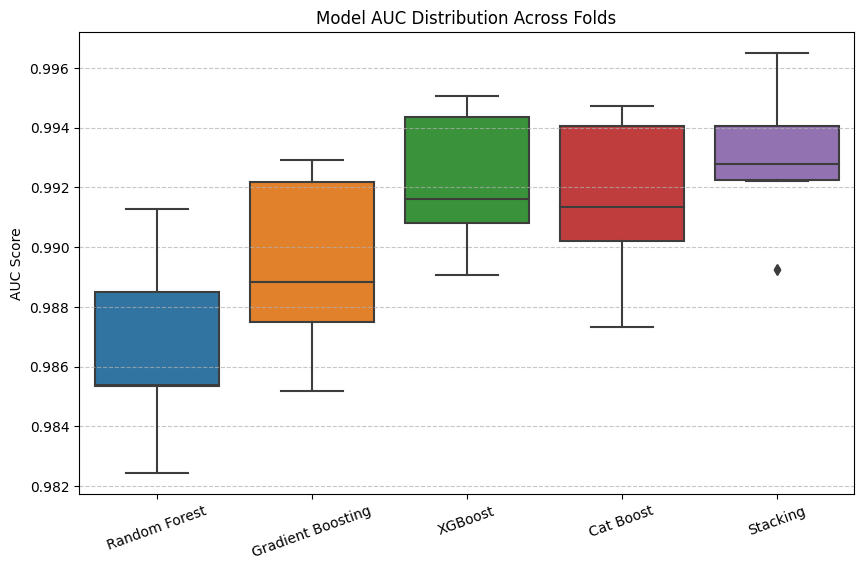

In [231]:
plt.figure(figsize=(10,6))
sns.boxplot(data=list(models.values()))

plt.xticks(ticks=range(len(model_names)), labels=model_names, rotation=20)
plt.title("Model AUC Distribution Across Folds")
plt.ylabel("AUC Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


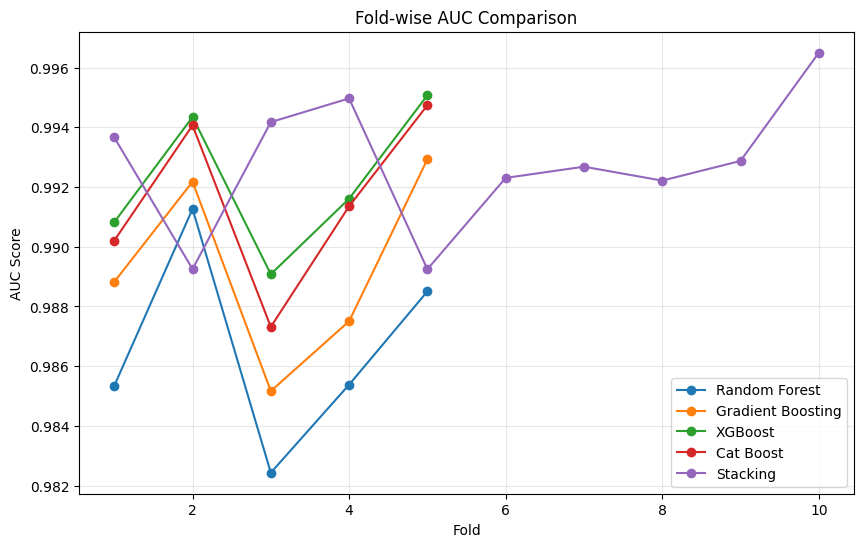

In [232]:
plt.figure(figsize=(10,6))

for name, scores in models.items():
    plt.plot(range(1, len(scores)+1), scores, marker='o', label=name)

plt.title("Fold-wise AUC Comparison")
plt.xlabel("Fold")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

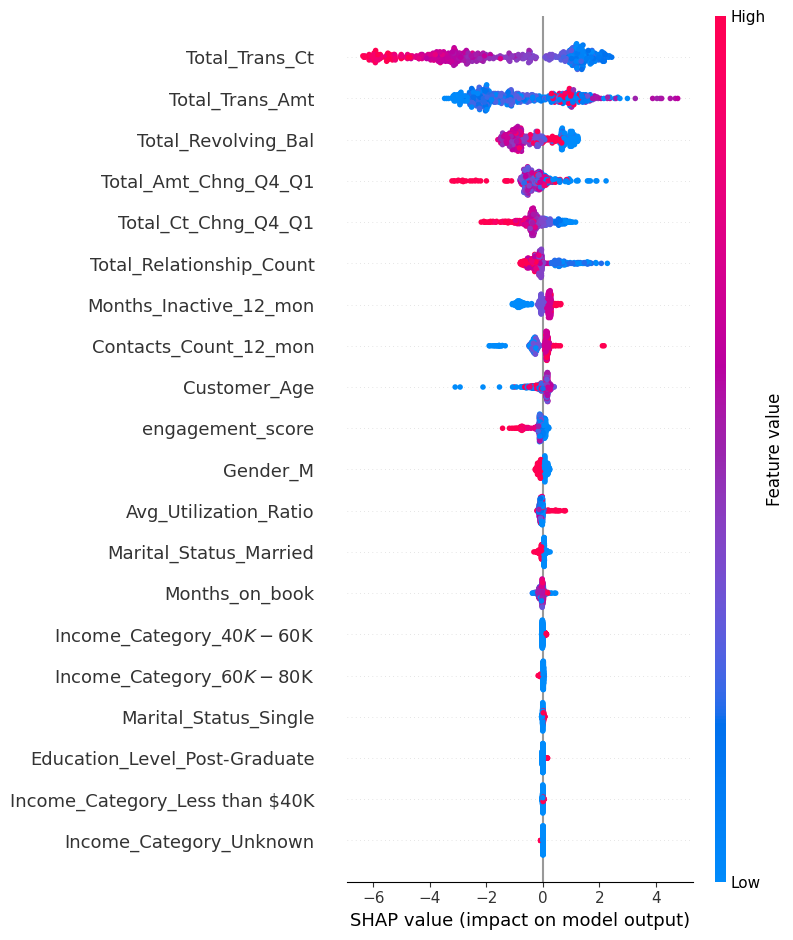

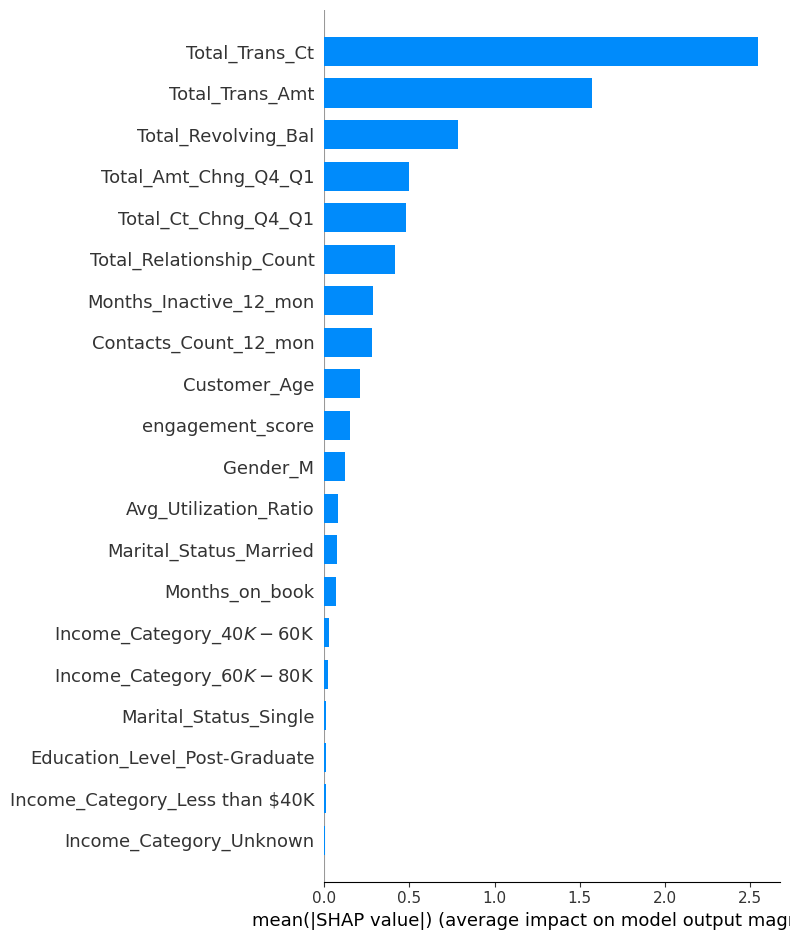

In [233]:
import shap
xgb_model = stack_model.named_estimators_['xgb']
X_sample = X_train.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)
shap.summary_plot(shap_values, X_sample, plot_type="bar")

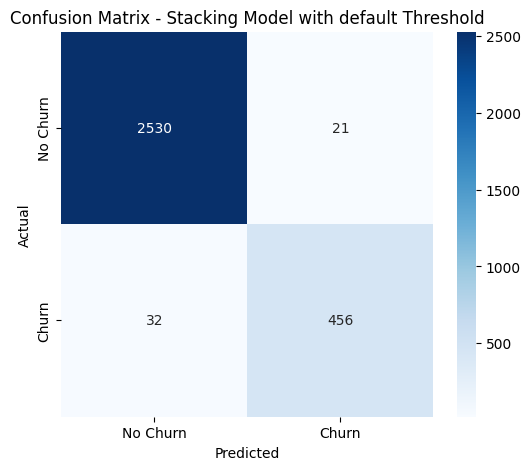

In [234]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = stack_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking Model with default Threshold")

plt.show()

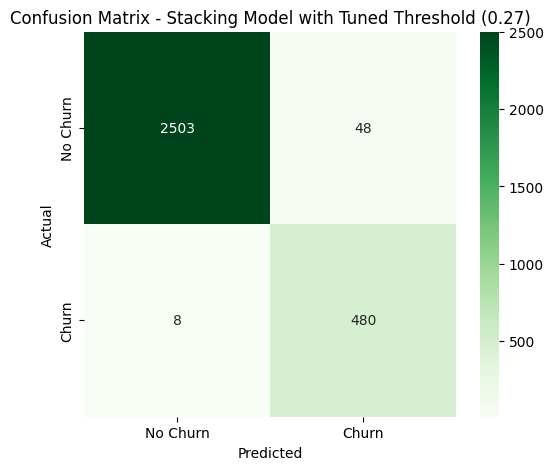

In [235]:
#confusion matrix for the stacking model with threshold tuning(0.2)
y_pred_thresh = (y_prob_stack >= 0.27).astype(int)
cm_thresh = confusion_matrix(y_test, y_pred_thresh)
plt.figure(figsize=(6,5))
sns.heatmap(cm_thresh, annot=True, fmt='d', cmap='Greens',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking Model with Tuned Threshold (0.27)")
plt.show()

In [236]:
print(stack_model)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=8,
                                                       min_samples_split=5,
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           n_estimators=200,
                                                           random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              

In [237]:
import joblib

joblib.dump(stack_model, "models/stacking_model.pkl")

['models/stacking_model.pkl']

In [238]:
threshold = 0.27

joblib.dump(threshold, "models/threshold.pkl")

['models/threshold.pkl']

In [247]:
import json

with open("models/features_in_order.json", "w") as f:
    json.dump(list(X_train.columns), f)

# Different Kinds of testing

In [240]:
Threshold = joblib.load("models/threshold.pkl")
loaded_model = joblib.load("models/stacking_model.pkl")
y_prob_test = loaded_model.predict_proba(X_test[:1000])[:, 1]
y_pred_test = (y_prob_test >= Threshold).astype(int)
y_pred_test

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,

In [248]:
print("Classification Report:")
print(classification_report(y_test, y_pred_thresh))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2551
           1       0.91      0.98      0.94       488

    accuracy                           0.98      3039
   macro avg       0.95      0.98      0.97      3039
weighted avg       0.98      0.98      0.98      3039



In [ ]:
print(list(X_train.columns))

['Customer_Age', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'engagement_score', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']


In [ ]:
print(list(X_test.columns))

['Customer_Age', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'engagement_score', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Income_Category_Unknown', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']


In [249]:
from sklearn.metrics import classification_report

y_prob_test1 = loaded_model.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob_test1 >= Threshold).astype(int)

print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2551
           1       0.91      0.98      0.94       488

    accuracy                           0.98      3039
   macro avg       0.95      0.98      0.97      3039
weighted avg       0.98      0.98      0.98      3039



In [ ]:
print(loaded_model)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=8,
                                                       min_samples_split=5,
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           n_estimators=200,
                                                           random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              

In [246]:
import sys
import sklearn
import xgboost
import numpy
import pandas
import joblib

print("Python:", sys.version)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

Python: 3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.4.4.1)]
sklearn: 1.3.2
xgboost: 1.7.6
numpy: 1.24.4
pandas: 2.0.3
joblib: 1.3.2
